In [1]:
import ast
import os
import gymnasium
import numpy as np
import matplotlib.pyplot as plt
import json
import sys

In [2]:
EPSILON_START = 0.75
EPSILON_END = 0.001
GAMMA = 0.99
LEARNING_RATES = [0.0, 0.1, 0.3, 0.5, 0.7, 1.0]
EPISODES = 8000
N_STEPS = [2, 3, 4]
FIG_SIZE = (10, 6)
MAX_ITERATIONS = int(5e5)
ERROR = 1e-5
REPETITIONS = 20

ENVIRONMENT = gymnasium.make("FrozenLake-v1", map_name="4x4", is_slippery=True).unwrapped


In [3]:
def linear_decay(episode):
    if episode >= 0.3 * EPISODES:
        return EPSILON_END
    return EPSILON_END + (EPSILON_START - EPSILON_END) * (1 - episode / EPISODES)

In [4]:
def compute_rmse(y_true, y_pred):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)

    return rmse

In [5]:
def epsilon_greedy(env, s, q, epsilon):
    prob = np.random.rand()
    if prob < epsilon:
        # print('Exploration')
        return env.action_space.sample()
    else:
        # print("Exploitation")
        return np.argmax([q[s, a] for a in range(env.action_space.n)])

In [6]:
def value_iteration(env, gamma=GAMMA, epsilon=ERROR, max_iterations=MAX_ITERATIONS):
    V = np.random.randn(env.observation_space.n)
    for i in range(max_iterations):
        delta = 0
        V_old = V.copy()
        for s in range(env.observation_space.n):
            v = V[s]
            V[s] = max(sum(p * (r + gamma * V_old[s_]) for p, s_, r, _ in env.P[s][a]) for a in range(env.action_space.n))
            delta = max(delta, abs(v - V[s]))
        if delta < epsilon:
            break
    return V

In [7]:
def q_learning(env, gamma, learning_rate, V_star):
    states = env.observation_space.n
    actions = env.action_space.n

    q = np.zeros((states, actions))

    # print(q)
    # print(q.shape)
    RMSE = []

    for episode in range(EPISODES):
        # print('Episode:', episode)
        curr_epsilon = linear_decay(episode)
        state, _ = env.reset()
        terminated = False
        cur_steps = 0
        while not terminated and cur_steps < MAX_ITERATIONS:
            action = epsilon_greedy(env, state, q, curr_epsilon)
            next_state, reward, terminated, _, _= env.step(action)
            q[state, action] = q[state, action] + learning_rate * (reward + gamma * max(q[next_state, :]) - q[state, action])
            state = next_state
            cur_steps += 1

        RMSE.append(compute_rmse([V_star[s] for s in range(states)], [max(q[s, :]) for s in range(states)]))

        # print(f"Done episode {episode}")
    pi = np.zeros(states)
    for s in range(states):
        pi[s] = np.argmax(q[s, :])
    return pi, RMSE

In [8]:
def sarsa(env, gamma, learning_rate, V_star):
    states = env.observation_space.n
    actions = env.action_space.n

    q = np.zeros((states, actions))
    # print(q)
    # print(q.shape)
    RMSE = []
    for episode in range(EPISODES):
        # print('Episode:', episode)
        curr_epsilon = linear_decay(episode)
        state, _ = env.reset()
        terminated = False
        curr_steps = 0
        action = epsilon_greedy(env, state, q, curr_epsilon)
        while not terminated and curr_steps < MAX_ITERATIONS:
            next_state, reward, terminated, _, _ = env.step(action)
            action_prime = epsilon_greedy(env, next_state, q, curr_epsilon)
            q[state, action] = q[state, action] + learning_rate * (reward + gamma * q[next_state, action_prime] - q[state, action])
            state = next_state
            action = action_prime
            curr_steps += 1

        RMSE.append(compute_rmse([V_star[s] for s in range(states)], [max(q[s, :]) for s in range(states)]))

    pi = np.zeros(states)
    for s in range(states):
        pi[s] = np.argmax(q[s, :])

    return pi, RMSE

In [9]:
def n_step_sarsa(env, gamma, learning_rate, V_star, n):
    states_n = env.observation_space.n
    actions_n = env.action_space.n

    q = np.zeros((states_n, actions_n))
    RMSE = []

    for episode in range(EPISODES):
        curr_epsilon = linear_decay(episode)
        state, _ = env.reset()
        terminated = False
        action_t = epsilon_greedy(env, state, q, curr_epsilon)
        curr_steps = 0

        T = sys.maxsize
        t = 0
        rewards = [0]
        states = [state]
        actions = [action_t]
        # print(f"Starting episode: {episode}")
        while True:
            if t < T:
                state_tp1, reward_tp1, terminated, _, _ = env.step(action_t)
                rewards.append(reward_tp1)
                states.append(state_tp1)
                if terminated:
                    T = t + 1
                else:
                    action_t = epsilon_greedy(env, state_tp1, q, curr_epsilon)
                    actions.append(action_t)

            tau = t - n + 1

            if tau >= 0:
                G = sum([gamma**(i - tau - 1) * rewards[i] for i in range(tau + 1, min(tau + n, T) + 1)])
                if tau + n < T:
                    G += gamma**n * q[states[tau + n], actions[tau + n]]
                q[states[tau], actions[tau]] += learning_rate * (G - q[states[tau], actions[tau]])

            if tau == T - 1 or curr_steps > MAX_ITERATIONS:
                break
            t += 1
            curr_steps += 1

        RMSE.append(compute_rmse([V_star[s] for s in range(states_n)], [max(q[s, :]) for s in range(states_n)]))
        # print(f"Ended episode: {episode}")

    pi = np.zeros(states_n)
    for s in range(states_n):
        pi[s] = np.argmax(q[s, :])

    return pi, RMSE

In [10]:
V_star = value_iteration(ENVIRONMENT)
print(V_star)

[ 5.41989461e-01  4.98766716e-01  4.70659219e-01  4.56815228e-01
  5.58414489e-01 -9.80761747e-04  3.58401552e-01  2.15392749e-04
  5.91762273e-01  6.43043353e-01  6.15189077e-01 -9.40613863e-04
  7.68239748e-05  7.41665977e-01  8.62764978e-01 -9.04423412e-05]


In [11]:
pi_q_learning, RMSE_q_learning = q_learning(ENVIRONMENT, GAMMA, LEARNING_RATES[3], V_star)
print(pi_q_learning)
print(RMSE_q_learning)

[0. 3. 3. 3. 0. 0. 0. 0. 3. 1. 0. 0. 0. 2. 1. 0.]
[np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.49050854

In [12]:
pi_sarsa, RMSE_sarsa = sarsa(ENVIRONMENT, GAMMA, LEARNING_RATES[3], V_star)
print(pi_sarsa)
print(RMSE_sarsa)

[0. 3. 0. 0. 0. 0. 0. 0. 3. 1. 0. 0. 0. 2. 1. 0.]
[np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.49050854

In [13]:
pi_n_sarsa, RMSE_n_sarsa = n_step_sarsa(ENVIRONMENT, GAMMA, LEARNING_RATES[3], V_star, N_STEPS[0])
print(pi_n_sarsa)
print(RMSE_n_sarsa)

[0. 3. 3. 3. 0. 0. 0. 0. 3. 1. 0. 0. 0. 2. 1. 0.]
[np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.4905085472108834), np.float64(0.42373348007019357), np.float64(0.42373348007019357), np.float64(0.42373348007019357), np.float64(0.42373348007019357), np.float64(0.42373348007019357), np.float64(0.42373348007019357), np.float64(0.42373348007019357), np.float64(0.42373348007019357), np.float64(0.42373348007019357), np.float64(0.42373348007019357), np.float64(0.41572979320811715), np.float64(0.41428282860136706), np.float6

In [14]:
def run_experiments():
    V_star = value_iteration(ENVIRONMENT)
    q_learning_errors = {}
    sarsa_errors = {}
    sarsa_2_errors = {}
    sarsa_3_errors = {}
    sarsa_4_errors = {}

    for learning_rate in LEARNING_RATES:
        total_rmse_q_learning = 0
        total_rmse_sarsa = 0
        total_rmse_2_sarsa = 0
        total_rmse_3_sarsa = 0
        total_rmse_4_sarsa = 0
        for rep in range(REPETITIONS):
            pi_q_learning, RMSE_q_learning = q_learning(ENVIRONMENT, GAMMA, learning_rate, V_star)
            pi_sarsa, RMSE_sarsa = sarsa(ENVIRONMENT, GAMMA, learning_rate, V_star)
            pi_2_sarsa, RMSE_2_sarsa = n_step_sarsa(ENVIRONMENT, GAMMA, learning_rate, V_star, N_STEPS[0])
            pi_3_sarsa, RMSE_3_sarsa = n_step_sarsa(ENVIRONMENT, GAMMA, learning_rate, V_star, N_STEPS[1])
            pi_4_sarsa, RMSE_4_sarsa = n_step_sarsa(ENVIRONMENT, GAMMA, learning_rate, V_star, N_STEPS[2])

            total_rmse_q_learning += RMSE_q_learning[-1]
            total_rmse_sarsa += RMSE_sarsa[-1]
            total_rmse_2_sarsa += RMSE_2_sarsa[-1]
            total_rmse_3_sarsa += RMSE_3_sarsa[-1]
            total_rmse_4_sarsa += RMSE_4_sarsa[-1]

        q_learning_errors[learning_rate] = total_rmse_q_learning / REPETITIONS
        sarsa_errors[learning_rate] = total_rmse_sarsa / REPETITIONS
        sarsa_2_errors[learning_rate] = total_rmse_2_sarsa / REPETITIONS
        sarsa_3_errors[learning_rate] = total_rmse_3_sarsa / REPETITIONS
        sarsa_4_errors[learning_rate] = total_rmse_4_sarsa / REPETITIONS

    plt.figure(figsize=FIG_SIZE)
    plt.plot(list(q_learning_errors.keys()), list(q_learning_errors.values()), label='Q-Learning')
    plt.plot(list(sarsa_errors.keys()), list(sarsa_errors.values()), label='SARSA')
    plt.plot(list(sarsa_2_errors.keys()), list(sarsa_2_errors.values()), label='2 steps SARSA')
    plt.plot(list(sarsa_3_errors.keys()), list(sarsa_3_errors.values()), label='3 steps SARSA')
    plt.plot(list(sarsa_4_errors.keys()), list(sarsa_4_errors.values()), label='4 steps SARSA')
    plt.xlabel('learning rate')
    plt.ylabel('RMSE')
    plt.legend()
    plt.title('Q-Learning, SARSA and n-step SARSA comparison')
    plt.savefig('./results/q_learning_sarsa.png')
    plt.show()
    plt.close()

FileNotFoundError: [Errno 2] No such file or directory: './results/q_learning_sarsa.png'

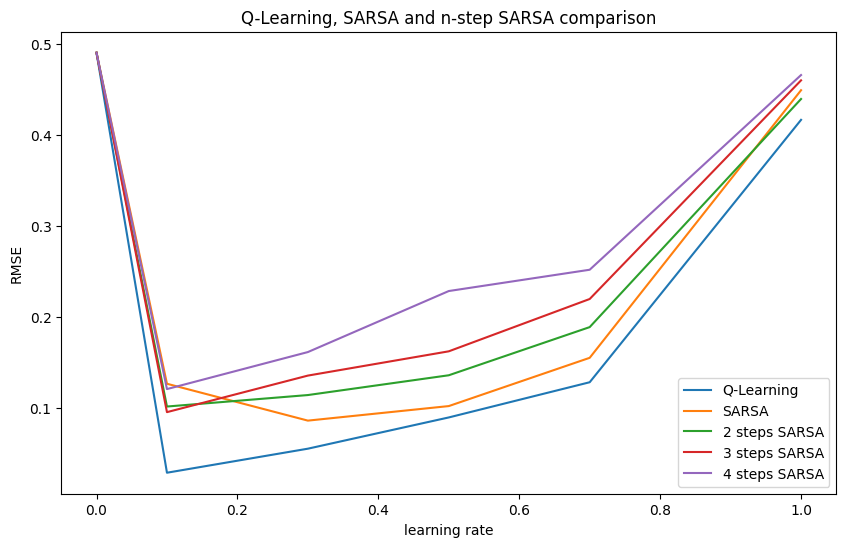

In [15]:
run_experiments()